# Model-Independent Preprocessing & Data Engineering

## Table Detection (TD) Pipeline

**Objective:** Global data preparation and preprocessing for table detection models. All exports are in COCO JSON format—model-specific conversions (e.g., YOLO `.txt`) happen in separate notebooks.

---

## Pipeline Overview

| Phase | Operation | Key Enhancement |
|-------|-----------|----------------|
| 1 | Global Configuration & Setup | Paths, split ratios, constants |
| 2 | Load & Parse COCO JSON | Build DataFrames, category mapping |
| 3 | Data Integrity & Cleaning | NMS dedup, orphan rescue, geometric clipping |
| 4 | Negative Sample Injection | **SKIPPED** (placeholder for future) |
| 5 | Spatial Standardization | 800×800 padding, coordinate transformation |
| 6 | Document-Grouped Splitting | 70/15/15 split with zero leakage |
| 7 | Pipeline Bifurcation | Sub-Dataset A (TD) + Sub-Dataset B (TSR) |
| 8 | Augmentation Plan | Configuration dict for future use |
| 9 | COCO JSON Export | Write cleaned splits to disk |
| 10 | Visual Verification | Overlay verification on exported data |

---

## Table of Contents

1. [Global Configuration & Setup](#config)
2. [Load & Parse COCO JSON](#load)
3. [Data Integrity & Cleaning](#cleaning)
   - 3.1 [Resolve Bounding Box Overlaps (NMS)](#nms)
   - 3.2 [Rescue Hierarchical Orphans](#orphans)
   - 3.3 [Geometric Clipping & Sanitization](#clipping)
4. [Negative Sample Injection (SKIPPED)](#negative)
5. [Spatial Standardization](#spatial)
6. [Document-Grouped Dataset Splitting](#splitting)
7. [Pipeline Bifurcation](#bifurcation)
   - 7.1 [Sub-Dataset A: Table Detection](#td)
   - 7.2 [Sub-Dataset B: Table Structure Recognition](#tsr)
8. [Universal Augmentation Plan](#augmentation)
9. [COCO JSON Export](#export)
10. [Visual Verification](#verification)

---

<a id='config'></a>
## 1. Global Configuration & Setup

In [1]:
import json
import os
import re
import copy
import warnings
from pathlib import Path
from collections import defaultdict
from typing import Dict, List, Tuple, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# =====================================================================
# PATHS  (Kaggle environment)
# =====================================================================
JSON_PATH   = '/kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/annotations/Cells_Anotations_coco.json'
IMAGES_DIR  = '/kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/images'
OUTPUT_ROOT = '/kaggle/working/preprocessed_dataset'  # Output directory for cleaned data

# Sub-directories for pipeline bifurcation
TD_OUTPUT_DIR  = os.path.join(OUTPUT_ROOT, 'table_detection')    # Sub-Dataset A
TSR_OUTPUT_DIR = os.path.join(OUTPUT_ROOT, 'table_structure')    # Sub-Dataset B

# =====================================================================
# DATASET SPLIT RATIOS
# =====================================================================
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-9, "Split ratios must sum to 1.0"

# =====================================================================
# SPATIAL STANDARDIZATION
# =====================================================================
TARGET_SIZE = 800           # Target dimension (longest side scaled to this)
PAD_COLOR   = (255, 255, 255)  # White padding (RGB)

# =====================================================================
# DATA CLEANING PARAMETERS
# =====================================================================
NMS_IOU_THRESHOLD   = 0.80   # IoU threshold for duplicate detection
ORPHAN_TOLERANCE_PX = 10     # Tolerance for expanding existing tables to capture orphans
MIN_BOX_AREA_PX     = 25     # Minimum box area (5x5 pixels) after clipping

# =====================================================================
# TSR CROP PARAMETERS
# =====================================================================
CROP_PAD_PX = 5  # Padding around table crops for context

# =====================================================================
# CATEGORY DEFINITIONS (from data_description.md)
# =====================================================================
# Category ID 1: table (the only target for Table Detection)
# Categories 2-6: table column, table row, table column header, 
#                 table projected row header, table spanning cell
TABLE_CATEGORY_ID = 1
STRUCTURAL_CATEGORY_IDS = [2, 3, 4, 5, 6]  # Non-table structural components

# =====================================================================
# DOCUMENT ID REGEX
# =====================================================================
DOC_ID_PATTERN = re.compile(r'^(PMC\d+)_\d+\.jpg$')

# =====================================================================
# VISUALIZATION
# =====================================================================
TABLE_COLOR = '#E74C3C'
STRUCTURAL_COLORS = {
    2: '#3498DB',  # table column - blue
    3: '#2ECC71',  # table row - green
    4: '#F39C12',  # table column header - orange
    5: '#9B59B6',  # table projected row header - purple
    6: '#1ABC9C',  # table spanning cell - teal
}
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("="*60)
print(" GLOBAL CONFIGURATION LOADED")
print("="*60)
print(f"\n   Train / Val / Test = {TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / {TEST_RATIO:.0%}")
print(f"   Target spatial size: {TARGET_SIZE}×{TARGET_SIZE}")
print(f"   NMS IoU threshold: {NMS_IOU_THRESHOLD}")
print(f"   Output root: {OUTPUT_ROOT}")
print(f"   Random seed: {RANDOM_SEED}")

 GLOBAL CONFIGURATION LOADED

   Train / Val / Test = 70% / 15% / 15%
   Target spatial size: 800×800
   NMS IoU threshold: 0.8
   Output root: /kaggle/working/preprocessed_dataset
   Random seed: 42


<a id='load'></a>
## 2. Load & Parse COCO JSON

In [2]:
# ============================================================
# Load COCO JSON
# ============================================================
with open(JSON_PATH, 'r') as f:
    coco_data = json.load(f)

images_list      = coco_data['images']
annotations_list = coco_data['annotations']
categories_list  = coco_data['categories']

print(f"   Loaded {len(images_list):,} images")
print(f"   Loaded {len(annotations_list):,} annotations")
print(f"   Loaded {len(categories_list)} categories")

# -------------------- Category Mapping --------------------
df_cats = pd.DataFrame(categories_list)
CAT_ID_TO_NAME = dict(zip(df_cats['id'], df_cats['name']))
CAT_NAME_TO_ID = dict(zip(df_cats['name'], df_cats['id']))

print("\n Categories:")
for _, row in df_cats.iterrows():
    marker = " <-- TD TARGET" if row['id'] == TABLE_CATEGORY_ID else "     (TSR component)"
    print(f"   {row['id']}: {row['name']} {marker}")

# -------------------- Images DataFrame --------------------
df_images = pd.DataFrame(images_list)
df_images = df_images.rename(columns={'id': 'image_id'})

# Extract document ID from filename  (PMC1064076_6.jpg --> PMC1064076)
df_images['doc_id'] = df_images['file_name'].apply(
    lambda f: DOC_ID_PATTERN.match(f).group(1) if DOC_ID_PATTERN.match(f) else f
)

# -------------------- Annotations DataFrame --------------------
df_anns = pd.DataFrame(annotations_list)
df_anns['bbox_x'] = df_anns['bbox'].apply(lambda b: b[0])
df_anns['bbox_y'] = df_anns['bbox'].apply(lambda b: b[1])
df_anns['bbox_w'] = df_anns['bbox'].apply(lambda b: b[2])
df_anns['bbox_h'] = df_anns['bbox'].apply(lambda b: b[3])

# Merge image metadata
df_anns = df_anns.merge(
    df_images[['image_id', 'file_name', 'width', 'height', 'doc_id']],
    on='image_id', how='left'
)
df_anns['category_name'] = df_anns['category_id'].map(CAT_ID_TO_NAME)

print(f"\n DataFrames built successfully.")
print(f"   df_images shape: {df_images.shape}")
print(f"   df_anns shape:   {df_anns.shape}")
print(f"   Unique documents: {df_images['doc_id'].nunique()}")

# Quick annotation breakdown
print("\n Annotations by category:")
for cat_id, cat_name in CAT_ID_TO_NAME.items():
    count = (df_anns['category_id'] == cat_id).sum()
    print(f"   {cat_name}: {count:,}")

   Loaded 1,500 images
   Loaded 36,850 annotations
   Loaded 6 categories

 Categories:
   1: table  <-- TD TARGET
   2: table column      (TSR component)
   3: table row      (TSR component)
   4: table column header      (TSR component)
   5: table projected row header      (TSR component)
   6: table spanning cell      (TSR component)

 DataFrames built successfully.
   df_images shape: (1500, 5)
   df_anns shape:   (36850, 16)
   Unique documents: 1459

 Annotations by category:
   table: 1,791
   table column: 8,274
   table row: 20,558
   table column header: 1,453
   table projected row header: 1,207
   table spanning cell: 3,567


<a id='cleaning'></a>
## 3. Data Integrity & Cleaning

**Objective:** Sanitize raw annotations by fixing contradictions and geometry errors before any formatting.

### Issues to Address (from EDA):
1. **218 annotation pairs** share >0.8 IoU (potential duplicates)
2. **473 non-table elements** exist outside parent `table` annotations (orphans)
3. **Tiny boxes** and edge-case coordinates that could crash model transforms

<a id='nms'></a>
### 3.1 Resolve Bounding Box Overlaps (Non-Maximum Suppression)

In [3]:
# ============================================================
# Phase 3.1: NMS-based Duplicate Resolution
# ============================================================

print("="*60)
print(" PHASE 3.1: NMS-BASED DUPLICATE RESOLUTION")
print("="*60)

def compute_iou(box1: Tuple[float, float, float, float], 
                box2: Tuple[float, float, float, float]) -> float:
    """
    Compute IoU between two boxes in [x, y, w, h] format.
    """
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    
    # Convert to [x1, y1, x2, y2]
    box1_x2, box1_y2 = x1 + w1, y1 + h1
    box2_x2, box2_y2 = x2 + w2, y2 + h2
    
    # Intersection
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(box1_x2, box2_x2)
    inter_y2 = min(box1_y2, box2_y2)
    
    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter_area = inter_w * inter_h
    
    # Union
    area1 = w1 * h1
    area2 = w2 * h2
    union_area = area1 + area2 - inter_area
    
    if union_area <= 0:
        return 0.0
    
    return inter_area / union_area


def apply_nms_per_image_category(df: pd.DataFrame, 
                                  iou_threshold: float = 0.80) -> Tuple[pd.DataFrame, List[Dict]]:
    """
    Apply NMS to remove duplicate annotations within the same image and category.
    Keeps the box with larger area for each duplicate pair.
    
    Returns:
        - Cleaned DataFrame with duplicates removed
        - Suppression log for auditability
    """
    suppression_log = []
    indices_to_drop = set()
    
    # Group by image and category
    for (img_id, cat_id), group in df.groupby(['image_id', 'category_id']):
        if len(group) < 2:
            continue
        
        # Sort by area descending (larger boxes first)
        group = group.copy()
        group['area_calc'] = group['bbox_w'] * group['bbox_h']
        group = group.sort_values('area_calc', ascending=False)
        
        indices = group.index.tolist()
        keep = []
        
        for i, idx in enumerate(indices):
            if idx in indices_to_drop:
                continue
            
            keep.append(idx)
            box_i = (group.loc[idx, 'bbox_x'], group.loc[idx, 'bbox_y'],
                     group.loc[idx, 'bbox_w'], group.loc[idx, 'bbox_h'])
            
            # Compare with remaining boxes
            for j in range(i + 1, len(indices)):
                idx_j = indices[j]
                if idx_j in indices_to_drop:
                    continue
                
                box_j = (group.loc[idx_j, 'bbox_x'], group.loc[idx_j, 'bbox_y'],
                         group.loc[idx_j, 'bbox_w'], group.loc[idx_j, 'bbox_h'])
                
                iou = compute_iou(box_i, box_j)
                
                if iou > iou_threshold:
                    indices_to_drop.add(idx_j)
                    suppression_log.append({
                        'image_id': img_id,
                        'category_id': cat_id,
                        'kept_ann_id': int(group.loc[idx, 'id']),
                        'suppressed_ann_id': int(group.loc[idx_j, 'id']),
                        'iou': round(iou, 4),
                        'kept_area': round(group.loc[idx, 'area_calc'], 2),
                        'suppressed_area': round(group.loc[idx_j, 'area_calc'], 2)
                    })
    
    # Drop suppressed indices
    df_cleaned = df.drop(index=list(indices_to_drop)).reset_index(drop=True)
    
    return df_cleaned, suppression_log


# Apply NMS
n_before_nms = len(df_anns)
df_anns_nms, nms_log = apply_nms_per_image_category(df_anns, iou_threshold=NMS_IOU_THRESHOLD)
n_after_nms = len(df_anns_nms)
n_suppressed = n_before_nms - n_after_nms

print(f"\n NMS Results:")
print(f"   Annotations before NMS: {n_before_nms:,}")
print(f"   Annotations after NMS:  {n_after_nms:,}")
print(f"   Duplicates suppressed:  {n_suppressed:,}")

# Log breakdown by category
if nms_log:
    df_nms_log = pd.DataFrame(nms_log)
    print(f"\n Suppression by category:")
    for cat_id in df_nms_log['category_id'].unique():
        count = (df_nms_log['category_id'] == cat_id).sum()
        cat_name = CAT_ID_TO_NAME.get(cat_id, f'Unknown({cat_id})')
        print(f"   {cat_name}: {count}")
    
    print(f"\n Sample suppression log (first 5):")
    for entry in nms_log[:5]:
        print(f"   Image {entry['image_id']}: kept ann {entry['kept_ann_id']} "
              f"(area={entry['kept_area']:.0f}), suppressed ann {entry['suppressed_ann_id']} "
              f"(area={entry['suppressed_area']:.0f}), IoU={entry['iou']:.3f}")
else:
    print("\n   No duplicates found above IoU threshold.")

# Update working DataFrame
df_anns = df_anns_nms.copy()

 PHASE 3.1: NMS-BASED DUPLICATE RESOLUTION

 NMS Results:
   Annotations before NMS: 36,850
   Annotations after NMS:  36,850
   Duplicates suppressed:  0

   No duplicates found above IoU threshold.


<a id='orphans'></a>
### 3.2 Rescue Hierarchical Orphans

**Problem:** 473 non-table structural components exist outside any parent `table` annotation.

**Strategy (Improved):**
1. First, check if orphans are merely slightly outside an existing table bbox (within tolerance)
2. If so, expand that table bbox instead of creating a synthetic one
3. Only truly parentless clusters get a new synthetic table annotation

In [4]:
# ============================================================
# Phase 3.2: Rescue Hierarchical Orphans
# ============================================================

print("="*60)
print(" PHASE 3.2: RESCUE HIERARCHICAL ORPHANS")
print("="*60)

def is_contained_with_tolerance(child_box: Tuple[float, float, float, float],
                                 parent_box: Tuple[float, float, float, float],
                                 tolerance: float = 0) -> bool:
    """
    Check if child_box is contained within parent_box with given tolerance.
    Boxes in [x, y, w, h] format.
    """
    cx, cy, cw, ch = child_box
    px, py, pw, ph = parent_box
    
    return (cx >= px - tolerance and
            cy >= py - tolerance and
            cx + cw <= px + pw + tolerance and
            cy + ch <= py + ph + tolerance)


def find_best_parent_table(child_box: Tuple[float, float, float, float],
                           tables: pd.DataFrame,
                           tolerance: float = 0) -> Optional[int]:
    """
    Find the best parent table for a child box.
    Returns the DataFrame index of the best parent, or None if not found.
    """
    cx, cy, cw, ch = child_box
    child_x2, child_y2 = cx + cw, cy + ch
    
    best_idx = None
    best_overlap = -1
    
    for idx, row in tables.iterrows():
        parent_box = (row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h'])
        
        # Check containment with tolerance
        if is_contained_with_tolerance(child_box, parent_box, tolerance):
            return idx  # Found containing parent
        
        # Track overlap for potential expansion
        px, py, pw, ph = parent_box
        px2, py2 = px + pw, py + ph
        
        inter_x1 = max(cx, px)
        inter_y1 = max(cy, py)
        inter_x2 = min(child_x2, px2)
        inter_y2 = min(child_y2, py2)
        
        overlap = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
        
        if overlap > best_overlap:
            best_overlap = overlap
            best_idx = idx
    
    return best_idx  # Return closest overlapping table (may be None)


# Separate table and structural annotations
df_tables = df_anns[df_anns['category_id'] == TABLE_CATEGORY_ID].copy()
df_structural = df_anns[df_anns['category_id'].isin(STRUCTURAL_CATEGORY_IDS)].copy()

print(f"\n Initial counts:")
print(f"   Table annotations: {len(df_tables):,}")
print(f"   Structural annotations: {len(df_structural):,}")

# Find orphans and attempt rescue
orphans = []
expansion_count = 0
expansion_log = []

# Group tables by image for efficient lookup
tables_by_image = {img_id: group for img_id, group in df_tables.groupby('image_id')}

for idx, row in tqdm(df_structural.iterrows(), total=len(df_structural), desc="Checking containment"):
    img_id = row['image_id']
    child_box = (row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h'])
    
    if img_id not in tables_by_image:
        # No tables on this image - definite orphan
        orphans.append(idx)
        continue
    
    img_tables = tables_by_image[img_id]
    
    # Check if contained in any table
    contained = False
    for t_idx, t_row in img_tables.iterrows():
        parent_box = (t_row['bbox_x'], t_row['bbox_y'], t_row['bbox_w'], t_row['bbox_h'])
        if is_contained_with_tolerance(child_box, parent_box, tolerance=ORPHAN_TOLERANCE_PX):
            contained = True
            break
    
    if not contained:
        orphans.append(idx)

print(f"\n Orphan detection:")
print(f"   Orphaned structural elements: {len(orphans):,}")

# ============================================================
# Rescue Strategy: Expand existing tables or create synthetic ones
# ============================================================

synthetic_tables = []  # New table annotations to add
new_ann_id = df_anns['id'].max() + 1  # Starting ID for new annotations

# Group orphans by image
orphan_df = df_structural.loc[orphans].copy()
orphans_by_image = {img_id: group for img_id, group in orphan_df.groupby('image_id')}

for img_id, img_orphans in orphans_by_image.items():
    img_w = img_orphans.iloc[0]['width']
    img_h = img_orphans.iloc[0]['height']
    file_name = img_orphans.iloc[0]['file_name']
    doc_id = img_orphans.iloc[0]['doc_id']
    
    # Get existing tables for this image
    if img_id in tables_by_image:
        img_tables = tables_by_image[img_id].copy()
    else:
        img_tables = pd.DataFrame()
    
    # Try to expand existing tables first
    remaining_orphans = []
    
    for o_idx, o_row in img_orphans.iterrows():
        orphan_box = (o_row['bbox_x'], o_row['bbox_y'], o_row['bbox_w'], o_row['bbox_h'])
        ox, oy, ow, oh = orphan_box
        ox2, oy2 = ox + ow, oy + oh
        
        # Find best overlapping table to expand
        best_table_idx = None
        best_overlap = 0
        
        for t_idx, t_row in img_tables.iterrows():
            tx, ty, tw, th = t_row['bbox_x'], t_row['bbox_y'], t_row['bbox_w'], t_row['bbox_h']
            tx2, ty2 = tx + tw, ty + th
            
            inter_x1 = max(ox, tx)
            inter_y1 = max(oy, ty)
            inter_x2 = min(ox2, tx2)
            inter_y2 = min(oy2, ty2)
            
            overlap = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
            
            if overlap > best_overlap:
                best_overlap = overlap
                best_table_idx = t_idx
        
        # If significant overlap, expand the table
        if best_overlap > 0 and best_table_idx is not None:
            t_row = img_tables.loc[best_table_idx]
            tx, ty, tw, th = t_row['bbox_x'], t_row['bbox_y'], t_row['bbox_w'], t_row['bbox_h']
            tx2, ty2 = tx + tw, ty + th
            
            # Expand to encompass orphan
            new_tx = min(tx, ox)
            new_ty = min(ty, oy)
            new_tx2 = max(tx2, ox2)
            new_ty2 = max(ty2, oy2)
            
            # Clip to image bounds
            new_tx = max(0, new_tx)
            new_ty = max(0, new_ty)
            new_tx2 = min(img_w, new_tx2)
            new_ty2 = min(img_h, new_ty2)
            
            new_tw = new_tx2 - new_tx
            new_th = new_ty2 - new_ty
            
            # Update table in working copy
            img_tables.at[best_table_idx, 'bbox_x'] = new_tx
            img_tables.at[best_table_idx, 'bbox_y'] = new_ty
            img_tables.at[best_table_idx, 'bbox_w'] = new_tw
            img_tables.at[best_table_idx, 'bbox_h'] = new_th
            
            # Also update main tables DataFrame
            if best_table_idx in df_tables.index:
                df_tables.at[best_table_idx, 'bbox_x'] = new_tx
                df_tables.at[best_table_idx, 'bbox_y'] = new_ty
                df_tables.at[best_table_idx, 'bbox_w'] = new_tw
                df_tables.at[best_table_idx, 'bbox_h'] = new_th
                df_tables.at[best_table_idx, 'bbox'] = [new_tx, new_ty, new_tw, new_th]
                df_tables.at[best_table_idx, 'area'] = new_tw * new_th
            
            expansion_count += 1
            expansion_log.append({
                'image_id': img_id,
                'file_name': file_name,
                'table_ann_id': int(t_row['id']),
                'orphan_ann_id': int(o_row['id']),
                'orphan_category': o_row['category_name']
            })
        else:
            remaining_orphans.append(o_row)
    
    # Create synthetic table for remaining orphans
    if remaining_orphans:
        # Compute bounding rectangle
        min_x = min(o['bbox_x'] for o in remaining_orphans)
        min_y = min(o['bbox_y'] for o in remaining_orphans)
        max_x = max(o['bbox_x'] + o['bbox_w'] for o in remaining_orphans)
        max_y = max(o['bbox_y'] + o['bbox_h'] for o in remaining_orphans)
        
        # Clip to image bounds
        min_x = max(0, min_x)
        min_y = max(0, min_y)
        max_x = min(img_w, max_x)
        max_y = min(img_h, max_y)
        
        syn_w = max_x - min_x
        syn_h = max_y - min_y
        
        if syn_w > 0 and syn_h > 0:
            synthetic_tables.append({
                'id': new_ann_id,
                'image_id': img_id,
                'category_id': TABLE_CATEGORY_ID,
                'bbox': [min_x, min_y, syn_w, syn_h],
                'bbox_x': min_x,
                'bbox_y': min_y,
                'bbox_w': syn_w,
                'bbox_h': syn_h,
                'area': syn_w * syn_h,
                'iscrowd': 0,
                'ignore': 0,
                'file_name': file_name,
                'width': img_w,
                'height': img_h,
                'doc_id': doc_id,
                'category_name': 'table',
                'is_synthetic': True  # Mark as synthetic
            })
            new_ann_id += 1

print(f"\n Rescue Results:")
print(f"   Tables expanded to capture orphans: {expansion_count}")
print(f"   Synthetic tables created: {len(synthetic_tables)}")

# Add synthetic tables to df_tables
if synthetic_tables:
    df_synthetic = pd.DataFrame(synthetic_tables)
    df_tables = pd.concat([df_tables, df_synthetic], ignore_index=True)
    print(f"   Total tables after rescue: {len(df_tables):,}")

if expansion_log:
    print(f"\n Sample expansions (first 5):")
    for entry in expansion_log[:5]:
        print(f"   {entry['file_name']}: expanded table {entry['table_ann_id']} "
              f"for orphan {entry['orphan_ann_id']} ({entry['orphan_category']})")

 PHASE 3.2: RESCUE HIERARCHICAL ORPHANS

 Initial counts:
   Table annotations: 1,791
   Structural annotations: 35,059


Checking containment:   0%|          | 0/35059 [00:00<?, ?it/s]


 Orphan detection:
   Orphaned structural elements: 0

 Rescue Results:
   Tables expanded to capture orphans: 0
   Synthetic tables created: 0


<a id='clipping'></a>
### 3.3 Geometric Clipping & Sanitization

In [5]:
# ============================================================
# Phase 3.3: Geometric Clipping & Sanitization
# ============================================================

print("="*60)
print(" PHASE 3.3: GEOMETRIC CLIPPING & SANITIZATION")
print("="*60)

def clip_and_sanitize_bbox(row: pd.Series, min_area: float = MIN_BOX_AREA_PX) -> Optional[Dict]:
    """
    Clip bbox to image bounds and check validity.
    Returns clipped bbox dict or None if invalid.
    """
    img_w, img_h = row['width'], row['height']
    x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
    
    # Compute corners
    x2 = x + w
    y2 = y + h
    
    # Clip to image bounds
    x_clipped = max(0, min(x, img_w))
    y_clipped = max(0, min(y, img_h))
    x2_clipped = max(0, min(x2, img_w))
    y2_clipped = max(0, min(y2, img_h))
    
    # Recompute width/height
    w_clipped = x2_clipped - x_clipped
    h_clipped = y2_clipped - y_clipped
    area_clipped = w_clipped * h_clipped
    
    # Check validity
    if w_clipped <= 0 or h_clipped <= 0 or area_clipped < min_area:
        return None
    
    return {
        'bbox_x': x_clipped,
        'bbox_y': y_clipped,
        'bbox_w': w_clipped,
        'bbox_h': h_clipped,
        'area': area_clipped,
        'was_clipped': (x != x_clipped or y != y_clipped or w != w_clipped or h != h_clipped)
    }


# Apply clipping to all annotations
n_clipped = 0
n_discarded = 0
indices_to_drop = []

for idx, row in df_anns.iterrows():
    result = clip_and_sanitize_bbox(row)
    
    if result is None:
        indices_to_drop.append(idx)
        n_discarded += 1
    else:
        if result['was_clipped']:
            n_clipped += 1
            df_anns.at[idx, 'bbox_x'] = result['bbox_x']
            df_anns.at[idx, 'bbox_y'] = result['bbox_y']
            df_anns.at[idx, 'bbox_w'] = result['bbox_w']
            df_anns.at[idx, 'bbox_h'] = result['bbox_h']
            df_anns.at[idx, 'bbox'] = [result['bbox_x'], result['bbox_y'], 
                                        result['bbox_w'], result['bbox_h']]
            df_anns.at[idx, 'area'] = result['area']

# Also apply to tables DataFrame
table_indices_to_drop = []
for idx, row in df_tables.iterrows():
    result = clip_and_sanitize_bbox(row)
    
    if result is None:
        table_indices_to_drop.append(idx)
    elif result['was_clipped']:
        df_tables.at[idx, 'bbox_x'] = result['bbox_x']
        df_tables.at[idx, 'bbox_y'] = result['bbox_y']
        df_tables.at[idx, 'bbox_w'] = result['bbox_w']
        df_tables.at[idx, 'bbox_h'] = result['bbox_h']
        df_tables.at[idx, 'bbox'] = [result['bbox_x'], result['bbox_y'], 
                                      result['bbox_w'], result['bbox_h']]
        df_tables.at[idx, 'area'] = result['area']

# Drop invalid annotations
df_anns = df_anns.drop(index=indices_to_drop).reset_index(drop=True)
df_tables = df_tables.drop(index=table_indices_to_drop).reset_index(drop=True)

print(f"\n Clipping Results:")
print(f"   Annotations clipped: {n_clipped}")
print(f"   Annotations discarded (invalid): {n_discarded}")
print(f"   Tables discarded: {len(table_indices_to_drop)}")
print(f"\n Final counts after Phase 3:")
print(f"   Total annotations: {len(df_anns):,}")
print(f"   Table annotations: {len(df_tables):,}")

# Summary of cleaning phase
print("\n" + "="*60)
print(" PHASE 3 COMPLETE: DATA INTEGRITY & CLEANING")
print("="*60)
print(f"   NMS duplicates removed: {n_suppressed}")
print(f"   Orphan rescues (expansions): {expansion_count}")
print(f"   Synthetic tables created: {len(synthetic_tables)}")
print(f"   Geometric clips: {n_clipped}")
print(f"   Invalid boxes discarded: {n_discarded}")

 PHASE 3.3: GEOMETRIC CLIPPING & SANITIZATION

 Clipping Results:
   Annotations clipped: 33933
   Annotations discarded (invalid): 0
   Tables discarded: 0

 Final counts after Phase 3:
   Total annotations: 36,850
   Table annotations: 1,791

 PHASE 3 COMPLETE: DATA INTEGRITY & CLEANING
   NMS duplicates removed: 0
   Orphan rescues (expansions): 0
   Synthetic tables created: 0
   Geometric clips: 33933
   Invalid boxes discarded: 0


<a id='negative'></a>
## 4. Negative Sample Injection (SKIPPED)

**Status:** This phase is **SKIPPED** per user instruction.

**Background:** A robust detector requires negative samples (images without tables) to reduce false positives. The EDA noted 0 empty images in the current dataset.

**Future Implementation Plan:**
1. Acquire 150-250 document images (10-15% of total) containing **no tables**
2. Register these images in the COCO JSON `images` block
3. Leave their corresponding annotations empty
4. This provides detectors with "background" examples for stable background-class modeling

**TODO:** Implement negative sample injection when background images are available.

In [6]:
# ============================================================
# Phase 4: Negative Sample Injection (PLACEHOLDER)
# ============================================================

print("="*60)
print(" PHASE 4: NEGATIVE SAMPLE INJECTION (SKIPPED)")
print("="*60)
print("\n   This phase is deferred for future implementation.")
print("   Current negative sample count: 0")
print("   Target negative sample count: ~150-250 (10-15% of dataset)")

# Placeholder for future implementation
NEGATIVE_SAMPLES_DIR = None  # '/path/to/negative/samples'
negative_images_added = 0

 PHASE 4: NEGATIVE SAMPLE INJECTION (SKIPPED)

   This phase is deferred for future implementation.
   Current negative sample count: 0
   Target negative sample count: ~150-250 (10-15% of dataset)


<a id='spatial'></a>
## 5. Spatial Standardization

**Objective:** Guarantee uniform resolution across all inputs while strictly avoiding aspect ratio distortion.

**Strategy:**
1. Scale longest dimension to `TARGET_SIZE` (800 pixels)
2. Pad shorter dimension with neutral color (white) to create uniform canvas
3. Transform all bounding box coordinates to match the new resolution

**Note:** This transformation is essential for models that expect fixed input sizes while preserving document proportions (typically 0.75-0.85 aspect ratio).

In [7]:
# ============================================================
# Phase 5: Spatial Standardization
# ============================================================

print("="*60)
print(" PHASE 5: SPATIAL STANDARDIZATION")
print("="*60)

def compute_resize_params(orig_w: int, orig_h: int, 
                          target_size: int = TARGET_SIZE) -> Dict[str, Any]:
    """
    Compute resize and padding parameters for aspect-preserving standardization.
    
    Returns dict with:
        - scale: Scale factor applied to both dimensions
        - new_w, new_h: Dimensions after scaling (before padding)
        - pad_left, pad_top: Padding offsets
        - final_w, final_h: Final dimensions (should be target_size x target_size)
    """
    # Scale longest dimension to target
    scale = target_size / max(orig_w, orig_h)
    
    new_w = int(round(orig_w * scale))
    new_h = int(round(orig_h * scale))
    
    # Compute symmetric padding
    pad_left = (target_size - new_w) // 2
    pad_top = (target_size - new_h) // 2
    
    return {
        'scale': scale,
        'new_w': new_w,
        'new_h': new_h,
        'pad_left': pad_left,
        'pad_top': pad_top,
        'final_w': target_size,
        'final_h': target_size
    }


def transform_bbox(bbox: List[float], 
                   resize_params: Dict[str, Any]) -> List[float]:
    """
    Transform bounding box coordinates to match resized/padded image.
    
    Args:
        bbox: [x, y, w, h] in original coordinates
        resize_params: Output from compute_resize_params
    
    Returns:
        Transformed [x, y, w, h]
    """
    x, y, w, h = bbox
    scale = resize_params['scale']
    pad_left = resize_params['pad_left']
    pad_top = resize_params['pad_top']
    
    # Scale coordinates
    new_x = x * scale + pad_left
    new_y = y * scale + pad_top
    new_w = w * scale
    new_h = h * scale
    
    return [new_x, new_y, new_w, new_h]


# Compute resize parameters for each image
resize_params_by_image = {}

for _, row in df_images.iterrows():
    img_id = row['image_id']
    resize_params_by_image[img_id] = compute_resize_params(
        row['width'], row['height'], TARGET_SIZE
    )

# Analyze resize statistics
scales = [p['scale'] for p in resize_params_by_image.values()]
print(f"\n Resize Statistics:")
print(f"   Target size: {TARGET_SIZE}×{TARGET_SIZE}")
print(f"   Scale factor range: [{min(scales):.4f}, {max(scales):.4f}]")
print(f"   Mean scale factor: {np.mean(scales):.4f}")

# Transform all annotations
print(f"\n Transforming {len(df_anns):,} annotations...")

for idx, row in tqdm(df_anns.iterrows(), total=len(df_anns), desc="Transforming coordinates"):
    img_id = row['image_id']
    params = resize_params_by_image[img_id]
    
    old_bbox = [row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']]
    new_bbox = transform_bbox(old_bbox, params)
    
    df_anns.at[idx, 'bbox'] = new_bbox
    df_anns.at[idx, 'bbox_x'] = new_bbox[0]
    df_anns.at[idx, 'bbox_y'] = new_bbox[1]
    df_anns.at[idx, 'bbox_w'] = new_bbox[2]
    df_anns.at[idx, 'bbox_h'] = new_bbox[3]
    df_anns.at[idx, 'area'] = new_bbox[2] * new_bbox[3]  # Recompute area

# Also transform table annotations
print(f" Transforming {len(df_tables):,} table annotations...")

for idx, row in df_tables.iterrows():
    img_id = row['image_id']
    params = resize_params_by_image[img_id]
    
    old_bbox = [row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']]
    new_bbox = transform_bbox(old_bbox, params)
    
    df_tables.at[idx, 'bbox'] = new_bbox
    df_tables.at[idx, 'bbox_x'] = new_bbox[0]
    df_tables.at[idx, 'bbox_y'] = new_bbox[1]
    df_tables.at[idx, 'bbox_w'] = new_bbox[2]
    df_tables.at[idx, 'bbox_h'] = new_bbox[3]
    df_tables.at[idx, 'area'] = new_bbox[2] * new_bbox[3]

# Update image dimensions in df_images
df_images['orig_width'] = df_images['width']
df_images['orig_height'] = df_images['height']
df_images['width'] = TARGET_SIZE
df_images['height'] = TARGET_SIZE

# Store resize params for later use
df_images['resize_scale'] = df_images['image_id'].map(
    lambda x: resize_params_by_image[x]['scale']
)
df_images['pad_left'] = df_images['image_id'].map(
    lambda x: resize_params_by_image[x]['pad_left']
)
df_images['pad_top'] = df_images['image_id'].map(
    lambda x: resize_params_by_image[x]['pad_top']
)

print(f"\n Spatial Standardization Complete:")
print(f"   All images standardized to: {TARGET_SIZE}×{TARGET_SIZE}")
print(f"   All bbox coordinates transformed")
print(f"   Resize parameters stored in df_images")

 PHASE 5: SPATIAL STANDARDIZATION

 Resize Statistics:
   Target size: 800×800
   Scale factor range: [0.8000, 0.8000]
   Mean scale factor: 0.8000

 Transforming 36,850 annotations...


Transforming coordinates:   0%|          | 0/36850 [00:00<?, ?it/s]

 Transforming 1,791 table annotations...

 Spatial Standardization Complete:
   All images standardized to: 800×800
   All bbox coordinates transformed
   Resize parameters stored in df_images


In [8]:
# ============================================================
# Verify Coordinate Transformation
# ============================================================

print("\n Coordinate Verification:")

# Check that all coordinates are within bounds
out_of_bounds = 0

for idx, row in df_anns.iterrows():
    x, y, w, h = row['bbox_x'], row['bbox_y'], row['bbox_w'], row['bbox_h']
    x2, y2 = x + w, y + h
    
    if x < 0 or y < 0 or x2 > TARGET_SIZE or y2 > TARGET_SIZE:
        out_of_bounds += 1

print(f"   Annotations out of bounds: {out_of_bounds}")

# Bbox statistics after transformation
print(f"\n Transformed BBox Statistics:")
print(f"   X range: [{df_anns['bbox_x'].min():.2f}, {(df_anns['bbox_x'] + df_anns['bbox_w']).max():.2f}]")
print(f"   Y range: [{df_anns['bbox_y'].min():.2f}, {(df_anns['bbox_y'] + df_anns['bbox_h']).max():.2f}]")
print(f"   Width range: [{df_anns['bbox_w'].min():.2f}, {df_anns['bbox_w'].max():.2f}]")
print(f"   Height range: [{df_anns['bbox_h'].min():.2f}, {df_anns['bbox_h'].max():.2f}]")
print(f"   Area range: [{df_anns['area'].min():.2f}, {df_anns['area'].max():.2f}]")


 Coordinate Verification:
   Annotations out of bounds: 0

 Transformed BBox Statistics:
   X range: [59.66, 720.70]
   Y range: [48.09, 758.46]
   Width range: [1.83, 650.19]
   Height range: [7.53, 682.38]
   Area range: [317.59, 316352.12]


<a id='splitting'></a>
## 6. Document-Grouped Dataset Splitting

**Objective:** Prevent data leakage by splitting at the document level.

**Problem:** Images from the same research paper (e.g., `PMC1064076_1.jpg`, `PMC1064076_2.jpg`) share styles, borders, and layout properties. Random splitting bleeds these properties across splits, artificially inflating scores.

**Strategy:** `GroupShuffleSplit` with document ID as the group key.
- **70% Training:** Primary model updates
- **15% Validation:** Hyperparameter tuning and early stopping
- **15% Testing:** Final evaluation metrics

In [9]:
# ============================================================
# Phase 6: Document-Grouped Dataset Splitting
# ============================================================

print("="*60)
print(" PHASE 6: DOCUMENT-GROUPED DATASET SPLITTING")
print("="*60)

# Build split DataFrame
df_split = df_images[['image_id', 'file_name', 'doc_id']].copy()

# Count table annotations per image
tables_per_image = df_tables.groupby('image_id').size().reset_index(name='n_tables')
df_split = df_split.merge(tables_per_image, on='image_id', how='left')
df_split['n_tables'] = df_split['n_tables'].fillna(0).astype(int)

# Count all annotations per image
anns_per_image = df_anns.groupby('image_id').size().reset_index(name='n_annotations')
df_split = df_split.merge(anns_per_image, on='image_id', how='left')
df_split['n_annotations'] = df_split['n_annotations'].fillna(0).astype(int)

n_docs = df_split['doc_id'].nunique()
print(f"\n Dataset Overview:")
print(f"   Total images: {len(df_split):,}")
print(f"   Unique documents: {n_docs}")
print(f"   Images with tables: {(df_split['n_tables'] > 0).sum():,}")
print(f"   Images without tables: {(df_split['n_tables'] == 0).sum():,}")

# ============================================================
# Two-Pass Splitting Strategy
# ============================================================

# Pass 1: Train vs Temp (val + test)
temp_ratio = VAL_RATIO + TEST_RATIO  # 0.30

gss1 = GroupShuffleSplit(n_splits=1, test_size=temp_ratio, random_state=RANDOM_SEED)
train_idx, temp_idx = next(gss1.split(df_split, groups=df_split['doc_id']))

df_train = df_split.iloc[train_idx].copy()
df_temp = df_split.iloc[temp_idx].copy()

# Pass 2: Val vs Test from temp
test_from_temp = TEST_RATIO / temp_ratio  # 0.15/0.30 = 0.5

gss2 = GroupShuffleSplit(n_splits=1, test_size=test_from_temp, random_state=RANDOM_SEED)
val_idx, test_idx = next(gss2.split(df_temp, groups=df_temp['doc_id']))

df_val = df_temp.iloc[val_idx].copy()
df_test = df_temp.iloc[test_idx].copy()

# Assign split labels
df_train['split'] = 'train'
df_val['split'] = 'val'
df_test['split'] = 'test'

df_all_splits = pd.concat([df_train, df_val, df_test], ignore_index=True)

# ============================================================
# Validate: Zero Document Overlap
# ============================================================

train_docs = set(df_train['doc_id'].unique())
val_docs = set(df_val['doc_id'].unique())
test_docs = set(df_test['doc_id'].unique())

leak_tv = train_docs & val_docs
leak_tt = train_docs & test_docs
leak_vt = val_docs & test_docs

print(f"\n" + "-"*60)
print(f" SPLIT STATISTICS")
print(f"-"*60)

for name, df_s in [('Train', df_train), ('Val', df_val), ('Test', df_test)]:
    n_imgs = len(df_s)
    n_tables = df_s['n_tables'].sum()
    n_anns = df_s['n_annotations'].sum()
    n_doc = df_s['doc_id'].nunique()
    pct = n_imgs / len(df_split) * 100
    
    print(f"\n   {name}:")
    print(f"      Images:       {n_imgs:,} ({pct:.1f}%)")
    print(f"      Tables:       {n_tables:,}")
    print(f"      Annotations:  {n_anns:,}")
    print(f"      Documents:    {n_doc}")

print(f"\n" + "-"*60)
print(f" DATA LEAKAGE CHECK")
print(f"-"*60)
print(f"   Train-Val overlap:  {len(leak_tv)} docs  {'OK' if len(leak_tv)==0 else 'LEAK!'})")
print(f"   Train-Test overlap: {len(leak_tt)} docs  {'OK' if len(leak_tt)==0 else 'LEAK!'}")
print(f"   Val-Test overlap:   {len(leak_vt)} docs  {'OK' if len(leak_vt)==0 else 'LEAK!'}")

assert len(leak_tv) == 0, "Data leakage between Train and Val!"
assert len(leak_tt) == 0, "Data leakage between Train and Test!"
assert len(leak_vt) == 0, "Data leakage between Val and Test!"

 PHASE 6: DOCUMENT-GROUPED DATASET SPLITTING

 Dataset Overview:
   Total images: 1,500
   Unique documents: 1459
   Images with tables: 1,500
   Images without tables: 0

------------------------------------------------------------
 SPLIT STATISTICS
------------------------------------------------------------

   Train:
      Images:       1,053 (70.2%)
      Tables:       1,254
      Annotations:  25,608
      Documents:    1021

   Val:
      Images:       223 (14.9%)
      Tables:       266
      Annotations:  5,598
      Documents:    219

   Test:
      Images:       224 (14.9%)
      Tables:       271
      Annotations:  5,644
      Documents:    219

------------------------------------------------------------
 DATA LEAKAGE CHECK
------------------------------------------------------------
   Train-Val overlap:  0 docs  OK)
   Train-Test overlap: 0 docs  OK
   Val-Test overlap:   0 docs  OK


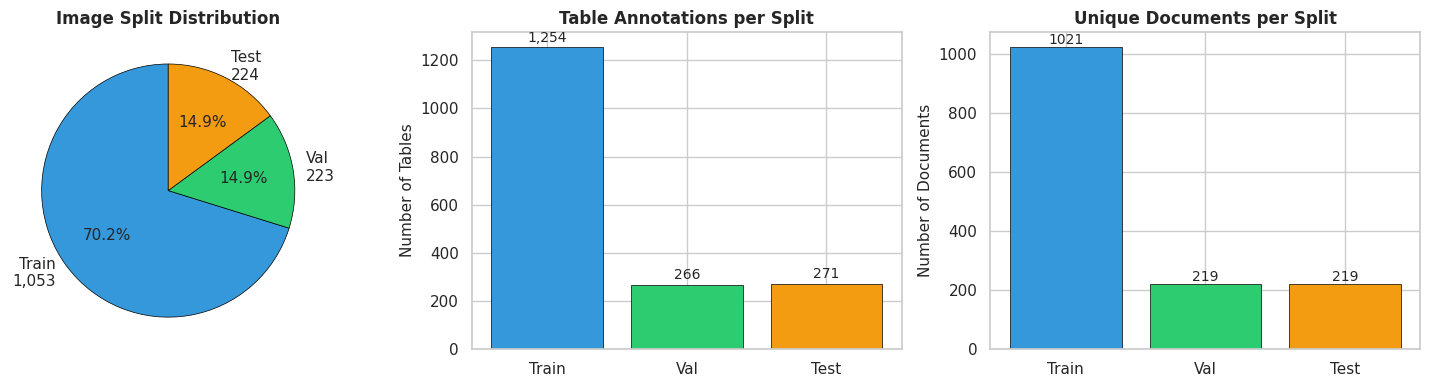

In [10]:
# ============================================================
# Visualization: Split Distribution
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Split distribution (pie)
ax1 = axes[0]
sizes = [len(df_train), len(df_val), len(df_test)]
labels = [f'Train\n{sizes[0]:,}', f'Val\n{sizes[1]:,}', f'Test\n{sizes[2]:,}']
colors = ['#3498DB', '#2ECC71', '#F39C12']
ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90,
        wedgeprops=dict(edgecolor='black', linewidth=0.5))
ax1.set_title('Image Split Distribution', fontsize=12, fontweight='bold')

# Tables per split (bar)
ax2 = axes[1]
split_names = ['Train', 'Val', 'Test']
split_tables = [df_train['n_tables'].sum(), df_val['n_tables'].sum(), df_test['n_tables'].sum()]
bars = ax2.bar(split_names, split_tables, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_ylabel('Number of Tables', fontsize=11)
ax2.set_title('Table Annotations per Split', fontsize=12, fontweight='bold')
for bar, val in zip(bars, split_tables):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{val:,}', ha='center', va='bottom', fontsize=10)

# Documents per split (bar)
ax3 = axes[2]
split_docs = [len(train_docs), len(val_docs), len(test_docs)]
bars = ax3.bar(split_names, split_docs, color=colors, edgecolor='black', linewidth=0.5)
ax3.set_ylabel('Number of Documents', fontsize=11)
ax3.set_title('Unique Documents per Split', fontsize=12, fontweight='bold')
for bar, val in zip(bars, split_docs):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'{val}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

<a id='bifurcation'></a>
## 7. Pipeline Bifurcation

**Objective:** Generate two discrete annotation datasets for cascaded frameworks.

### Sub-Dataset A: Table Detection (Macro)
- Keep only Category 1 (`table`)
- Drop Categories 2-6
- Full images with table-only annotations

### Sub-Dataset B: Table Structure Recognition (Micro)
- Crop regions containing tables
- Keep only Categories 2-6 (structural components)
- Translate coordinates to crop-relative origins

<a id='td'></a>
### 7.1 Sub-Dataset A: Table Detection

In [11]:
# ============================================================
# Phase 7.1: Sub-Dataset A - Table Detection
# ============================================================

print("="*60)
print(" PHASE 7.1: SUB-DATASET A - TABLE DETECTION")
print("="*60)

def create_td_coco_dict(df_imgs: pd.DataFrame, 
                        df_tables_split: pd.DataFrame,
                        split_name: str) -> Dict:
    """
    Create COCO format dictionary for Table Detection sub-dataset.
    """
    # Images
    images = []
    for _, row in df_imgs.iterrows():
        images.append({
            'id': int(row['image_id']),
            'file_name': row['file_name'],
            'width': TARGET_SIZE,
            'height': TARGET_SIZE,
            'orig_width': int(row.get('orig_width', row['width'])),
            'orig_height': int(row.get('orig_height', row['height']))
        })
    
    # Annotations (tables only)
    annotations = []
    for _, row in df_tables_split.iterrows():
        annotations.append({
            'id': int(row['id']),
            'image_id': int(row['image_id']),
            'category_id': 1,  # Table (renumbered to 1 for single-class)
            'bbox': [float(row['bbox_x']), float(row['bbox_y']), 
                     float(row['bbox_w']), float(row['bbox_h'])],
            'area': float(row['area']),
            'iscrowd': 0,
            'ignore': 0
        })
    
    # Categories
    categories = [{
        'id': 1,
        'name': 'table',
        'supercategory': 'document_element'
    }]
    
    return {
        'info': {
            'description': f'Table Detection Dataset - {split_name}',
            'version': '1.0',
            'preprocessing': 'Model-independent global preprocessing',
            'spatial_size': f'{TARGET_SIZE}x{TARGET_SIZE}'
        },
        'images': images,
        'annotations': annotations,
        'categories': categories
    }


# Create TD datasets for each split
td_datasets = {}

for split_name, df_split_subset in [('train', df_train), ('val', df_val), ('test', df_test)]:
    # Get image IDs for this split
    split_img_ids = set(df_split_subset['image_id'].values)
    
    # Get images and tables for this split
    df_imgs_split = df_images[df_images['image_id'].isin(split_img_ids)]
    df_tables_split = df_tables[df_tables['image_id'].isin(split_img_ids)]
    
    # Create COCO dict
    td_datasets[split_name] = create_td_coco_dict(
        df_imgs_split, df_tables_split, split_name
    )
    
    print(f"\n   {split_name.capitalize()}:")
    print(f"      Images: {len(td_datasets[split_name]['images']):,}")
    print(f"      Table annotations: {len(td_datasets[split_name]['annotations']):,}")

print(f"\n Table Detection sub-datasets created successfully.")

 PHASE 7.1: SUB-DATASET A - TABLE DETECTION

   Train:
      Images: 1,053
      Table annotations: 1,254

   Val:
      Images: 223
      Table annotations: 266

   Test:
      Images: 224
      Table annotations: 271

 Table Detection sub-datasets created successfully.


<a id='tsr'></a>
### 7.2 Sub-Dataset B: Table Structure Recognition

**Process:**
1. For each table, define a crop region (with optional padding)
2. Filter structural annotations that fall within this region
3. Translate coordinates to crop-relative origins (0, 0)

In [12]:
# ============================================================
# Phase 7.2: Sub-Dataset B - Table Structure Recognition
# ============================================================

print("="*60)
print(" PHASE 7.2: SUB-DATASET B - TABLE STRUCTURE RECOGNITION")
print("="*60)

def extract_tsr_crops(df_tables: pd.DataFrame,
                      df_anns: pd.DataFrame,
                      structural_cat_ids: List[int],
                      crop_padding: int = CROP_PAD_PX) -> Tuple[List[Dict], List[Dict]]:
    """
    Extract TSR crops and translate structural annotations.
    
    Returns:
        - List of crop image metadata
        - List of translated annotations
    """
    crop_images = []
    crop_annotations = []
    crop_id = 1
    ann_id = 1
    
    # Remap category IDs for TSR (1-5 for structural components)
    tsr_cat_remap = {old_id: new_id for new_id, old_id in enumerate(structural_cat_ids, 1)}
    
    for _, table_row in df_tables.iterrows():
        img_id = table_row['image_id']
        file_name = table_row['file_name']
        table_id = table_row['id']
        
        # Table bbox (after spatial standardization)
        tx, ty, tw, th = (table_row['bbox_x'], table_row['bbox_y'],
                          table_row['bbox_w'], table_row['bbox_h'])
        
        # Crop region with padding
        crop_x = max(0, tx - crop_padding)
        crop_y = max(0, ty - crop_padding)
        crop_x2 = min(TARGET_SIZE, tx + tw + crop_padding)
        crop_y2 = min(TARGET_SIZE, ty + th + crop_padding)
        crop_w = crop_x2 - crop_x
        crop_h = crop_y2 - crop_y
        
        if crop_w <= 0 or crop_h <= 0:
            continue
        
        # Generate crop filename
        stem = Path(file_name).stem
        crop_filename = f"{stem}_table{table_id}.jpg"
        
        # Add crop image metadata
        crop_images.append({
            'id': crop_id,
            'file_name': crop_filename,
            'width': int(crop_w),
            'height': int(crop_h),
            'source_image_id': int(img_id),
            'source_file_name': file_name,
            'table_ann_id': int(table_id),
            'crop_origin': [float(crop_x), float(crop_y)]
        })
        
        # Find structural annotations within this table
        img_structural = df_anns[
            (df_anns['image_id'] == img_id) &
            (df_anns['category_id'].isin(structural_cat_ids))
        ]
        
        for _, struct_row in img_structural.iterrows():
            sx, sy, sw, sh = (struct_row['bbox_x'], struct_row['bbox_y'],
                              struct_row['bbox_w'], struct_row['bbox_h'])
            
            # Check if annotation is within or overlaps table bbox
            sx2 = sx + sw
            sy2 = sy + sh
            
            # Check overlap with table region
            if not (sx2 > tx and sx < tx + tw and sy2 > ty and sy < ty + th):
                continue  # Not within this table
            
            # Translate to crop coordinates
            new_x = sx - crop_x
            new_y = sy - crop_y
            
            # Clip to crop bounds
            new_x = max(0, min(new_x, crop_w))
            new_y = max(0, min(new_y, crop_h))
            new_w = min(sw, crop_w - new_x)
            new_h = min(sh, crop_h - new_y)
            
            if new_w <= 0 or new_h <= 0:
                continue
            
            crop_annotations.append({
                'id': ann_id,
                'image_id': crop_id,
                'category_id': tsr_cat_remap[struct_row['category_id']],
                'bbox': [float(new_x), float(new_y), float(new_w), float(new_h)],
                'area': float(new_w * new_h),
                'iscrowd': 0,
                'ignore': 0,
                'source_ann_id': int(struct_row['id']),
                'original_category_id': int(struct_row['category_id'])
            })
            ann_id += 1
        
        crop_id += 1
    
    return crop_images, crop_annotations


# TSR categories (remapped)
TSR_CATEGORIES = [
    {'id': 1, 'name': 'table_column', 'supercategory': 'table_structure'},
    {'id': 2, 'name': 'table_row', 'supercategory': 'table_structure'},
    {'id': 3, 'name': 'table_column_header', 'supercategory': 'table_structure'},
    {'id': 4, 'name': 'table_projected_row_header', 'supercategory': 'table_structure'},
    {'id': 5, 'name': 'table_spanning_cell', 'supercategory': 'table_structure'}
]

# Create TSR datasets for each split
tsr_datasets = {}

for split_name, df_split_subset in [('train', df_train), ('val', df_val), ('test', df_test)]:
    # Get image IDs for this split
    split_img_ids = set(df_split_subset['image_id'].values)
    
    # Get tables for this split
    df_tables_split = df_tables[df_tables['image_id'].isin(split_img_ids)]
    
    # Extract crops
    crop_images, crop_annotations = extract_tsr_crops(
        df_tables_split, df_anns, STRUCTURAL_CATEGORY_IDS, CROP_PAD_PX
    )
    
    tsr_datasets[split_name] = {
        'info': {
            'description': f'Table Structure Recognition Dataset - {split_name}',
            'version': '1.0',
            'preprocessing': 'Cropped from TD dataset',
            'crop_padding': CROP_PAD_PX
        },
        'images': crop_images,
        'annotations': crop_annotations,
        'categories': TSR_CATEGORIES
    }
    
    print(f"\n   {split_name.capitalize()}:")
    print(f"      Crop images: {len(crop_images):,}")
    print(f"      Structural annotations: {len(crop_annotations):,}")

print(f"\n Table Structure Recognition sub-datasets created successfully.")

 PHASE 7.2: SUB-DATASET B - TABLE STRUCTURE RECOGNITION

   Train:
      Crop images: 1,254
      Structural annotations: 24,354

   Val:
      Crop images: 266
      Structural annotations: 5,332

   Test:
      Crop images: 271
      Structural annotations: 5,373

 Table Structure Recognition sub-datasets created successfully.


In [13]:
# ============================================================
# TSR Category Distribution
# ============================================================

print("\n TSR Annotation Distribution:")

for split_name in ['train', 'val', 'test']:
    anns = tsr_datasets[split_name]['annotations']
    if anns:
        df_tsr_anns = pd.DataFrame(anns)
        print(f"\n   {split_name.capitalize()}:")
        for cat in TSR_CATEGORIES:
            count = (df_tsr_anns['category_id'] == cat['id']).sum()
            print(f"      {cat['name']}: {count:,}")


 TSR Annotation Distribution:

   Train:
      table_column: 5,706
      table_row: 14,347
      table_column_header: 1,004
      table_projected_row_header: 826
      table_spanning_cell: 2,471

   Val:
      table_column: 1,312
      table_row: 3,064
      table_column_header: 233
      table_projected_row_header: 167
      table_spanning_cell: 556

   Test:
      table_column: 1,256
      table_row: 3,147
      table_column_header: 216
      table_projected_row_header: 214
      table_spanning_cell: 540


<a id='augmentation'></a>
## 8. Universal Augmentation Plan

**Objective:** Define augmentations as a configuration that can be consumed by any DataLoader/augmentation library (e.g., Albumentations).

**Note:** This is configuration only—actual augmentation happens during training in model-specific notebooks.

In [14]:
# ============================================================
# Phase 8: Universal Augmentation Plan (Configuration)
# ============================================================

print("="*60)
print(" PHASE 8: UNIVERSAL AUGMENTATION PLAN")
print("="*60)

# Augmentation configuration dictionary
# Can be directly consumed by Albumentations or similar libraries

AUGMENTATION_CONFIG = {
    'description': 'Universal augmentation plan for document table detection',
    'version': '1.0',
    
    # =====================================================
    # GEOMETRIC AUGMENTATIONS (require bbox transformation)
    # =====================================================
    'geometric': {
        'horizontal_flip': {
            'enabled': True,
            'probability': 0.3,  # Rare - documents usually have consistent orientation
            'description': 'Horizontal mirroring - re-anchors bbox x coordinates'
        },
        'vertical_flip': {
            'enabled': False,  # Documents are rarely upside down
            'probability': 0.0,
            'description': 'Vertical flip - not recommended for documents'
        },
        'rotation': {
            'enabled': True,
            'probability': 0.2,
            'limit_degrees': 5,  # Small rotations for scan misalignment
            'border_mode': 'constant',
            'border_value': [255, 255, 255],  # White fill
            'description': 'Subtle rotation to simulate scanning errors'
        },
        'perspective': {
            'enabled': True,
            'probability': 0.15,
            'scale': [0.02, 0.05],  # Mild distortion
            'description': 'Perspective distortion for camera/scanner artifacts'
        },
        'affine': {
            'enabled': True,
            'probability': 0.15,
            'scale': [0.95, 1.05],     # Slight scaling
            'translate_percent': 0.02,  # Small translation
            'shear': [-2, 2],           # Minimal shear
            'description': 'Affine transformations for layout variation'
        }
    },
    
    # =====================================================
    # PHOTOMETRIC AUGMENTATIONS (bbox unchanged)
    # =====================================================
    'photometric': {
        'brightness_contrast': {
            'enabled': True,
            'probability': 0.4,
            'brightness_limit': 0.15,
            'contrast_limit': 0.15,
            'description': 'Brightness/contrast for varying document quality'
        },
        'hsv_shift': {
            'enabled': True,
            'probability': 0.3,
            'hue_shift_limit': 10,
            'sat_shift_limit': 15,
            'val_shift_limit': 15,
            'description': 'HSV adjustments for ink/paper color variation'
        },
        'grayscale': {
            'enabled': True,
            'probability': 0.1,
            'description': 'Convert to grayscale (some docs are B&W)'
        },
        'blur': {
            'enabled': True,
            'probability': 0.2,
            'blur_limit': 3,
            'description': 'Gaussian blur for low-quality scans'
        },
        'noise': {
            'gauss_noise': {
                'enabled': True,
                'probability': 0.15,
                'var_limit': [5, 20],
                'description': 'Gaussian noise for scanner artifacts'
            },
            'iso_noise': {
                'enabled': True,
                'probability': 0.1,
                'intensity': [0.1, 0.3],
                'description': 'ISO noise for camera capture'
            }
        },
        'jpeg_compression': {
            'enabled': True,
            'probability': 0.2,
            'quality_lower': 50,
            'quality_upper': 95,
            'description': 'JPEG artifacts from compression'
        }
    },
    
    # =====================================================
    # DOCUMENT-SPECIFIC AUGMENTATIONS
    # =====================================================
    'document_specific': {
        'shadow': {
            'enabled': True,
            'probability': 0.1,
            'num_shadows': [1, 2],
            'description': 'Simulated page shadows/folds'
        },
        'grid_distortion': {
            'enabled': True,
            'probability': 0.1,
            'distort_limit': 0.1,
            'description': 'Grid distortion for page warping'
        }
    },
    
    # =====================================================
    # COMPOSE STRATEGY
    # =====================================================
    'compose': {
        'bbox_format': 'coco',  # [x, y, width, height]
        'min_area': 100,        # Drop boxes below this area after transform
        'min_visibility': 0.3,  # Drop boxes with less than 30% visible
        'label_fields': ['category_id']
    }
}

print("\n Augmentation Configuration Created:")
print(f"\n   Geometric transforms: {len(AUGMENTATION_CONFIG['geometric'])}")
for name, cfg in AUGMENTATION_CONFIG['geometric'].items():
    status = 'Enabled' if cfg['enabled'] else 'Disabled'
    print(f"      - {name}: {status} (p={cfg['probability']})")

print(f"\n   Photometric transforms: {len(AUGMENTATION_CONFIG['photometric'])}")
for name, cfg in AUGMENTATION_CONFIG['photometric'].items():
    if isinstance(cfg, dict) and 'enabled' in cfg:
        status = 'Enabled' if cfg['enabled'] else 'Disabled'
        print(f"      - {name}: {status}")

print(f"\n   Document-specific transforms: {len(AUGMENTATION_CONFIG['document_specific'])}")
for name, cfg in AUGMENTATION_CONFIG['document_specific'].items():
    status = 'Enabled' if cfg['enabled'] else 'Disabled'
    print(f"      - {name}: {status}")

print("\n Note: This is configuration only. Actual augmentation happens during training.")

 PHASE 8: UNIVERSAL AUGMENTATION PLAN

 Augmentation Configuration Created:

   Geometric transforms: 5
      - horizontal_flip: Enabled (p=0.3)
      - vertical_flip: Disabled (p=0.0)
      - rotation: Enabled (p=0.2)
      - perspective: Enabled (p=0.15)
      - affine: Enabled (p=0.15)

   Photometric transforms: 6
      - brightness_contrast: Enabled
      - hsv_shift: Enabled
      - grayscale: Enabled
      - blur: Enabled
      - jpeg_compression: Enabled

   Document-specific transforms: 2
      - shadow: Enabled
      - grid_distortion: Enabled

 Note: This is configuration only. Actual augmentation happens during training.


<a id='export'></a>
## 9. COCO JSON Export

**Export Structure:**
```
preprocessed_dataset/
├── table_detection/          # Sub-Dataset A
│   ├── train.json
│   ├── val.json
│   ├── test.json
│   └── augmentation_config.json
├── table_structure/          # Sub-Dataset B
│   ├── train.json
│   ├── val.json
│   └── test.json
└── metadata.json             # Pipeline metadata
```

In [15]:
# ============================================================
# Phase 9: COCO JSON Export
# ============================================================

print("="*60)
print(" PHASE 9: COCO JSON EXPORT")
print("="*60)

# Create output directories
os.makedirs(TD_OUTPUT_DIR, exist_ok=True)
os.makedirs(TSR_OUTPUT_DIR, exist_ok=True)

# ============================================================
# Export Table Detection datasets
# ============================================================
print("\n Exporting Table Detection datasets...")

for split_name in ['train', 'val', 'test']:
    output_path = os.path.join(TD_OUTPUT_DIR, f'{split_name}.json')
    with open(output_path, 'w') as f:
        json.dump(td_datasets[split_name], f, indent=2)
    print(f"   Saved: {output_path}")

# Export augmentation config
aug_config_path = os.path.join(TD_OUTPUT_DIR, 'augmentation_config.json')
with open(aug_config_path, 'w') as f:
    json.dump(AUGMENTATION_CONFIG, f, indent=2)
print(f"   Saved: {aug_config_path}")

# ============================================================
# Export Table Structure Recognition datasets
# ============================================================
print("\n Exporting Table Structure Recognition datasets...")

for split_name in ['train', 'val', 'test']:
    output_path = os.path.join(TSR_OUTPUT_DIR, f'{split_name}.json')
    with open(output_path, 'w') as f:
        json.dump(tsr_datasets[split_name], f, indent=2)
    print(f"   Saved: {output_path}")

# ============================================================
# Export Pipeline Metadata
# ============================================================
print("\n Exporting pipeline metadata...")

metadata = {
    'pipeline': {
        'name': 'Model-Independent Preprocessing Pipeline',
        'version': '1.0',
        'output_format': 'COCO JSON'
    },
    'source': {
        'json_path': JSON_PATH,
        'images_dir': IMAGES_DIR,
        'total_images': len(df_images),
        'total_annotations': len(df_anns)
    },
    'cleaning': {
        'nms_threshold': NMS_IOU_THRESHOLD,
        'duplicates_removed': n_suppressed,
        'orphans_rescued': expansion_count,
        'synthetic_tables_created': len(synthetic_tables),
        'invalid_boxes_discarded': n_discarded
    },
    'spatial_standardization': {
        'target_size': TARGET_SIZE,
        'padding_color': PAD_COLOR
    },
    'splits': {
        'train_ratio': TRAIN_RATIO,
        'val_ratio': VAL_RATIO,
        'test_ratio': TEST_RATIO,
        'random_seed': RANDOM_SEED,
        'train_images': len(df_train),
        'val_images': len(df_val),
        'test_images': len(df_test),
        'train_documents': len(train_docs),
        'val_documents': len(val_docs),
        'test_documents': len(test_docs)
    },
    'table_detection': {
        'num_categories': 1,
        'train_annotations': len(td_datasets['train']['annotations']),
        'val_annotations': len(td_datasets['val']['annotations']),
        'test_annotations': len(td_datasets['test']['annotations'])
    },
    'table_structure': {
        'num_categories': len(TSR_CATEGORIES),
        'crop_padding': CROP_PAD_PX,
        'train_crops': len(tsr_datasets['train']['images']),
        'val_crops': len(tsr_datasets['val']['images']),
        'test_crops': len(tsr_datasets['test']['images']),
        'train_annotations': len(tsr_datasets['train']['annotations']),
        'val_annotations': len(tsr_datasets['val']['annotations']),
        'test_annotations': len(tsr_datasets['test']['annotations'])
    }
}

metadata_path = os.path.join(OUTPUT_ROOT, 'metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"   Saved: {metadata_path}")

# ============================================================
# Export resize parameters for image processing
# ============================================================
resize_params_export = {}
for img_id, params in resize_params_by_image.items():
    resize_params_export[str(img_id)] = params

resize_params_path = os.path.join(OUTPUT_ROOT, 'resize_params.json')
with open(resize_params_path, 'w') as f:
    json.dump(resize_params_export, f, indent=2)
print(f"   Saved: {resize_params_path}")

print(f"\n Export Complete!")
print(f"   Output directory: {OUTPUT_ROOT}")

 PHASE 9: COCO JSON EXPORT

 Exporting Table Detection datasets...
   Saved: /kaggle/working/preprocessed_dataset/table_detection/train.json
   Saved: /kaggle/working/preprocessed_dataset/table_detection/val.json
   Saved: /kaggle/working/preprocessed_dataset/table_detection/test.json
   Saved: /kaggle/working/preprocessed_dataset/table_detection/augmentation_config.json

 Exporting Table Structure Recognition datasets...
   Saved: /kaggle/working/preprocessed_dataset/table_structure/train.json
   Saved: /kaggle/working/preprocessed_dataset/table_structure/val.json
   Saved: /kaggle/working/preprocessed_dataset/table_structure/test.json

 Exporting pipeline metadata...
   Saved: /kaggle/working/preprocessed_dataset/metadata.json
   Saved: /kaggle/working/preprocessed_dataset/resize_params.json

 Export Complete!
   Output directory: /kaggle/working/preprocessed_dataset


<a id='verification'></a>
## 10. Visual Verification

**Objective:** End-to-end overlay verification on the transformed data to ensure correctness of all transformations.

 PHASE 10: VISUAL VERIFICATION

 Verifying 4 samples from training set...
   (Visualization requires images at: /kaggle/input/datasets/mohammedahmedxx12/machathon-dataset/Phase1_Train_Dataset/images)


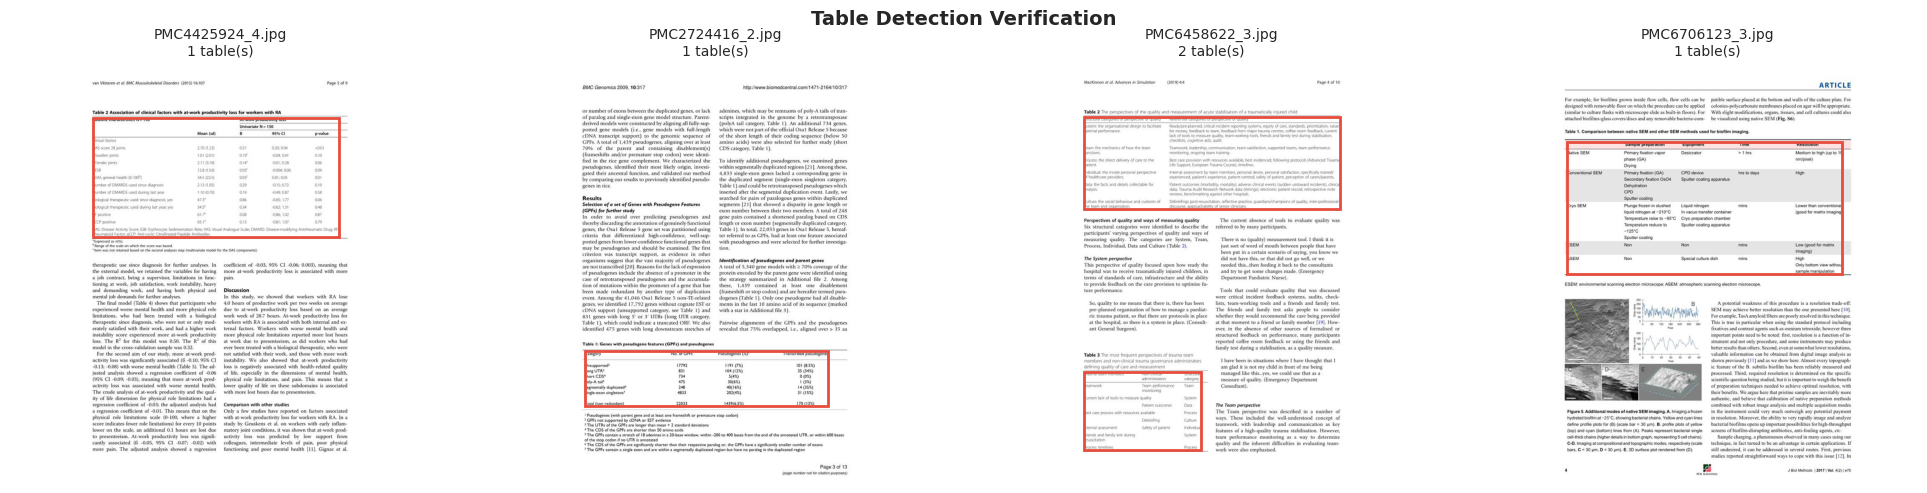

In [16]:
# ============================================================
# Phase 10: Visual Verification (Table Detection)
# ============================================================

print("="*60)
print(" PHASE 10: VISUAL VERIFICATION")
print("="*60)

def resize_and_pad_image(img: Image.Image, 
                         resize_params: Dict[str, Any],
                         pad_color: Tuple[int, int, int] = PAD_COLOR) -> Image.Image:
    """
    Apply the same resize and padding transformation to an image.
    """
    new_w = resize_params['new_w']
    new_h = resize_params['new_h']
    pad_left = resize_params['pad_left']
    pad_top = resize_params['pad_top']
    target = resize_params['final_w']
    
    # Resize
    img_resized = img.resize((new_w, new_h), Image.LANCZOS)
    
    # Create padded canvas
    canvas = Image.new('RGB', (target, target), pad_color)
    canvas.paste(img_resized, (pad_left, pad_top))
    
    return canvas


def visualize_td_sample(td_dataset: Dict, 
                        sample_indices: List[int],
                        images_dir: str,
                        resize_params_dict: Dict) -> None:
    """
    Visualize Table Detection samples with bounding boxes.
    """
    n_samples = len(sample_indices)
    fig, axes = plt.subplots(1, n_samples, figsize=(5 * n_samples, 5))
    if n_samples == 1:
        axes = [axes]
    
    images = td_dataset['images']
    annotations = td_dataset['annotations']
    
    # Build annotation lookup
    anns_by_image = defaultdict(list)
    for ann in annotations:
        anns_by_image[ann['image_id']].append(ann)
    
    for ax, idx in zip(axes, sample_indices):
        if idx >= len(images):
            ax.axis('off')
            continue
        
        img_meta = images[idx]
        img_id = img_meta['id']
        file_name = img_meta['file_name']
        
        # Load and transform image
        img_path = os.path.join(images_dir, file_name)
        if os.path.exists(img_path):
            img = Image.open(img_path).convert('RGB')
            params = resize_params_dict.get(img_id, compute_resize_params(
                img.width, img.height, TARGET_SIZE
            ))
            img_transformed = resize_and_pad_image(img, params)
            ax.imshow(img_transformed)
        else:
            # Create placeholder
            ax.imshow(np.ones((TARGET_SIZE, TARGET_SIZE, 3)))
            ax.text(TARGET_SIZE//2, TARGET_SIZE//2, 'Image not found',
                    ha='center', va='center', fontsize=12)
        
        # Draw bounding boxes
        img_anns = anns_by_image[img_id]
        for ann in img_anns:
            x, y, w, h = ann['bbox']
            rect = Rectangle((x, y), w, h,
                              linewidth=2, edgecolor=TABLE_COLOR,
                              facecolor='none')
            ax.add_patch(rect)
        
        ax.set_title(f'{file_name}\n{len(img_anns)} table(s)', fontsize=10)
        ax.axis('off')
    
    plt.suptitle('Table Detection Verification', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# Select random samples for visualization
np.random.seed(RANDOM_SEED)
n_verify = min(4, len(td_datasets['train']['images']))
verify_indices = np.random.choice(len(td_datasets['train']['images']), n_verify, replace=False)

print(f"\n Verifying {n_verify} samples from training set...")
print(f"   (Visualization requires images at: {IMAGES_DIR})")

# Note: This will only work if IMAGES_DIR is accessible
try:
    visualize_td_sample(
        td_datasets['train'],
        verify_indices.tolist(),
        IMAGES_DIR,
        resize_params_by_image
    )
except Exception as e:
    print(f"\n   Visualization skipped: {e}")
    print(f"   (Images not accessible at current path)")

In [18]:
# ============================================================
# Final Summary Report
# ============================================================

print("\n" + "="*60)
print(" PREPROCESSING PIPELINE COMPLETE")
print("="*60)

print("\n SUMMARY:")
print(f"\n   Source Data:")
print(f"      Images: {len(df_images):,}")
print(f"      Original annotations: {len(annotations_list):,}")

print(f"\n   Data Cleaning:")
print(f"      NMS duplicates removed: {n_suppressed}")
print(f"      Orphans rescued (table expansion): {expansion_count}")
print(f"      Synthetic tables created: {len(synthetic_tables)}")
print(f"      Invalid boxes discarded: {n_discarded}")

print(f"\n   Spatial Standardization:")
print(f"      Output size: {TARGET_SIZE}×{TARGET_SIZE}")
print(f"      Padding color: RGB{PAD_COLOR}")

print(f"\n   Dataset Splits (by document):")
print(f"      Train: {len(df_train):,} images ({len(train_docs)} docs)")
print(f"      Val:   {len(df_val):,} images ({len(val_docs)} docs)")
print(f"      Test:  {len(df_test):,} images ({len(test_docs)} docs)")
print(f"      Data leakage: None detected")

print(f"\n   Table Detection (Sub-Dataset A):")
print(f"      Categories: 1 (table)")
print(f"      Train: {len(td_datasets['train']['annotations']):,} annotations")
print(f"      Val:   {len(td_datasets['val']['annotations']):,} annotations")
print(f"      Test:  {len(td_datasets['test']['annotations']):,} annotations")

print(f"\n   Table Structure Recognition (Sub-Dataset B):")
print(f"      Categories: {len(TSR_CATEGORIES)}")
print(f"      Train: {len(tsr_datasets['train']['images']):,} crops, "
      f"{len(tsr_datasets['train']['annotations']):,} annotations")
print(f"      Val:   {len(tsr_datasets['val']['images']):,} crops, "
      f"{len(tsr_datasets['val']['annotations']):,} annotations")
print(f"      Test:  {len(tsr_datasets['test']['images']):,} crops, "
      f"{len(tsr_datasets['test']['annotations']):,} annotations")

print(f"\n   Output Files:")
print(f"      Table Detection: {TD_OUTPUT_DIR}/{{train,val,test}}.json")
print(f"      Table Structure: {TSR_OUTPUT_DIR}/{{train,val,test}}.json")
print(f"      Augmentation Config: {TD_OUTPUT_DIR}/augmentation_config.json")
print(f"      Metadata: {OUTPUT_ROOT}/metadata.json")
print(f"      Resize Params: {OUTPUT_ROOT}/resize_params.json")


 PREPROCESSING PIPELINE COMPLETE

 SUMMARY:

   Source Data:
      Images: 1,500
      Original annotations: 36,850

   Data Cleaning:
      NMS duplicates removed: 0
      Orphans rescued (table expansion): 0
      Synthetic tables created: 0
      Invalid boxes discarded: 0

   Spatial Standardization:
      Output size: 800×800
      Padding color: RGB(255, 255, 255)

   Dataset Splits (by document):
      Train: 1,053 images (1021 docs)
      Val:   223 images (219 docs)
      Test:  224 images (219 docs)
      Data leakage: None detected

   Table Detection (Sub-Dataset A):
      Categories: 1 (table)
      Train: 1,254 annotations
      Val:   266 annotations
      Test:  271 annotations

   Table Structure Recognition (Sub-Dataset B):
      Categories: 5
      Train: 1,254 crops, 24,354 annotations
      Val:   266 crops, 5,332 annotations
      Test:  271 crops, 5,373 annotations

   Output Files:
      Table Detection: /kaggle/working/preprocessed_dataset/table_detection/{tra